## Plot frequency spectra of boulder events

### Import libraries

In [2]:
import pandas as pd
from obspy import read,UTCDateTime
from datetime import datetime, timedelta
import numpy as np
from matplotlib import pyplot as plt
import os
import glob
import sys
from matplotlib import gridspec
from scipy import signal
from matplotlib import cm

# Import functions
fxndir = '../functions/'
sys.path.insert(0,fxndir)
from moon2data import *

### Obtain example of LM event

In [3]:
# Input variables
parentdir = '/data/ytamama/Apollo17/LSPE_data/sac_volts_ds/'
minfreq = 3
maxfreq = ''
befwin = 10
aftwin = 80
fs = 117.6

# Get spectrogram
mqdir = '../catalogs/final_catalogs/LM_vs_boulder_vs_other/'
cat_LM = pd.read_csv(mqdir + 'A17_LM_catalog_HQ_avg_event_stats.csv')
row_LM = cat_LM.loc[cat_LM.evid_ref == '761226-15-M1'].iloc[0]
arrtime = datetime.strptime(row_LM.avg_picktime_SNR,'%Y-%m-%d %H:%M:%S.%f')
st = moon2sac(arrtime,3,befwin,aftwin,minfreq,maxfreq,parentdir)
trtimes_LM = st.traces[0].times()
trdata_LM = st.traces[0].data
freqs_LM, times_LM, spec_LM = signal.spectrogram(trdata_LM, fs)

### Obtain example of other thermal moonquake

In [4]:
cat_other = pd.read_csv(mqdir + 'A17_other_catalog_HQ_avg_event_stats.csv')
row_other = cat_other.iloc[0]
arrtime = datetime.strptime(row_other.avg_picktime_SNR,'%Y-%m-%d %H:%M:%S.%f')
st = moon2sac(arrtime,3,befwin,aftwin,minfreq,maxfreq,parentdir)
trtimes_other = st.traces[0].times() 
trdata_other = st.traces[0].data
freqs_other, times_other, spec_other = signal.spectrogram(trdata_other, fs)

### Obtain examples of boulder-quakes 

In [5]:
# Geophone Rock
cat_georock = pd.read_csv(mqdir + 'GeophoneRock_events_catalog_HQ_avg_event_stats.csv')
row_georock = cat_georock.loc[cat_georock.evid == '761028-23-M3'].iloc[0]
arrtime = datetime.strptime(row_georock.avg_picktime_SNR,'%Y-%m-%d %H:%M:%S.%f')
st = moon2sac(arrtime,3,befwin,aftwin,minfreq,maxfreq,parentdir)
trtimes_georock = st.traces[0].times() 
trdata_georock = st.traces[0].data
freqs_georock, times_georock, spec_georock = signal.spectrogram(trdata_georock, fs)

# R2
cat_R2 = pd.read_csv(mqdir + 'R2Rock_events_catalog_HQ_avg_event_stats.csv')
row_R2 = cat_R2.loc[cat_R2.evid == '770423-21-M6'].iloc[0]
arrtime = datetime.strptime(row_R2.avg_picktime_SNR,'%Y-%m-%d %H:%M:%S.%f')
st = moon2sac(arrtime,3,befwin,aftwin,minfreq,maxfreq,parentdir)
trtimes_R2 = st.traces[0].times() 
trdata_R2 = st.traces[0].data
freqs_R2, times_R2, spec_R2 = signal.spectrogram(trdata_R2, fs)

# Geophone 4 Rock 1
cat_rock1 = pd.read_csv(mqdir + 'GEO4Rock1_events_catalog_HQ_avg_event_stats.csv')
row_rock1 = cat_rock1.loc[cat_rock1.evid == '761011-11-M2'].iloc[0]
arrtime = datetime.strptime(row_rock1.avg_picktime_SNR,'%Y-%m-%d %H:%M:%S.%f')
st = moon2sac(arrtime,4,befwin,aftwin,minfreq,maxfreq,parentdir)
trtimes_rock1 = st.traces[0].times() 
trdata_rock1 = st.traces[0].data
freqs_rock1, times_rock1, spec_rock1 = signal.spectrogram(trdata_rock1, fs)

# Geophone 4 Rock 2/3
cat_rock23 = pd.read_csv(mqdir + 'GEO4Rock2or3_events_catalog_HQ_avg_event_stats.csv')
row_rock23 = cat_rock23.loc[cat_rock23.evid == '761111-14-M5'].iloc[0]
arrtime = datetime.strptime(row_rock23.avg_picktime_SNR,'%Y-%m-%d %H:%M:%S.%f')
st = moon2sac(arrtime,4,befwin,aftwin,minfreq,maxfreq,parentdir)
trtimes_rock23 = st.traces[0].times() 
trdata_rock23 = st.traces[0].data
freqs_rock23, times_rock23, spec_rock23 = signal.spectrogram(trdata_rock23, fs)

### Plot spectrograms 

Style consistent with Civilini et al. (2023)

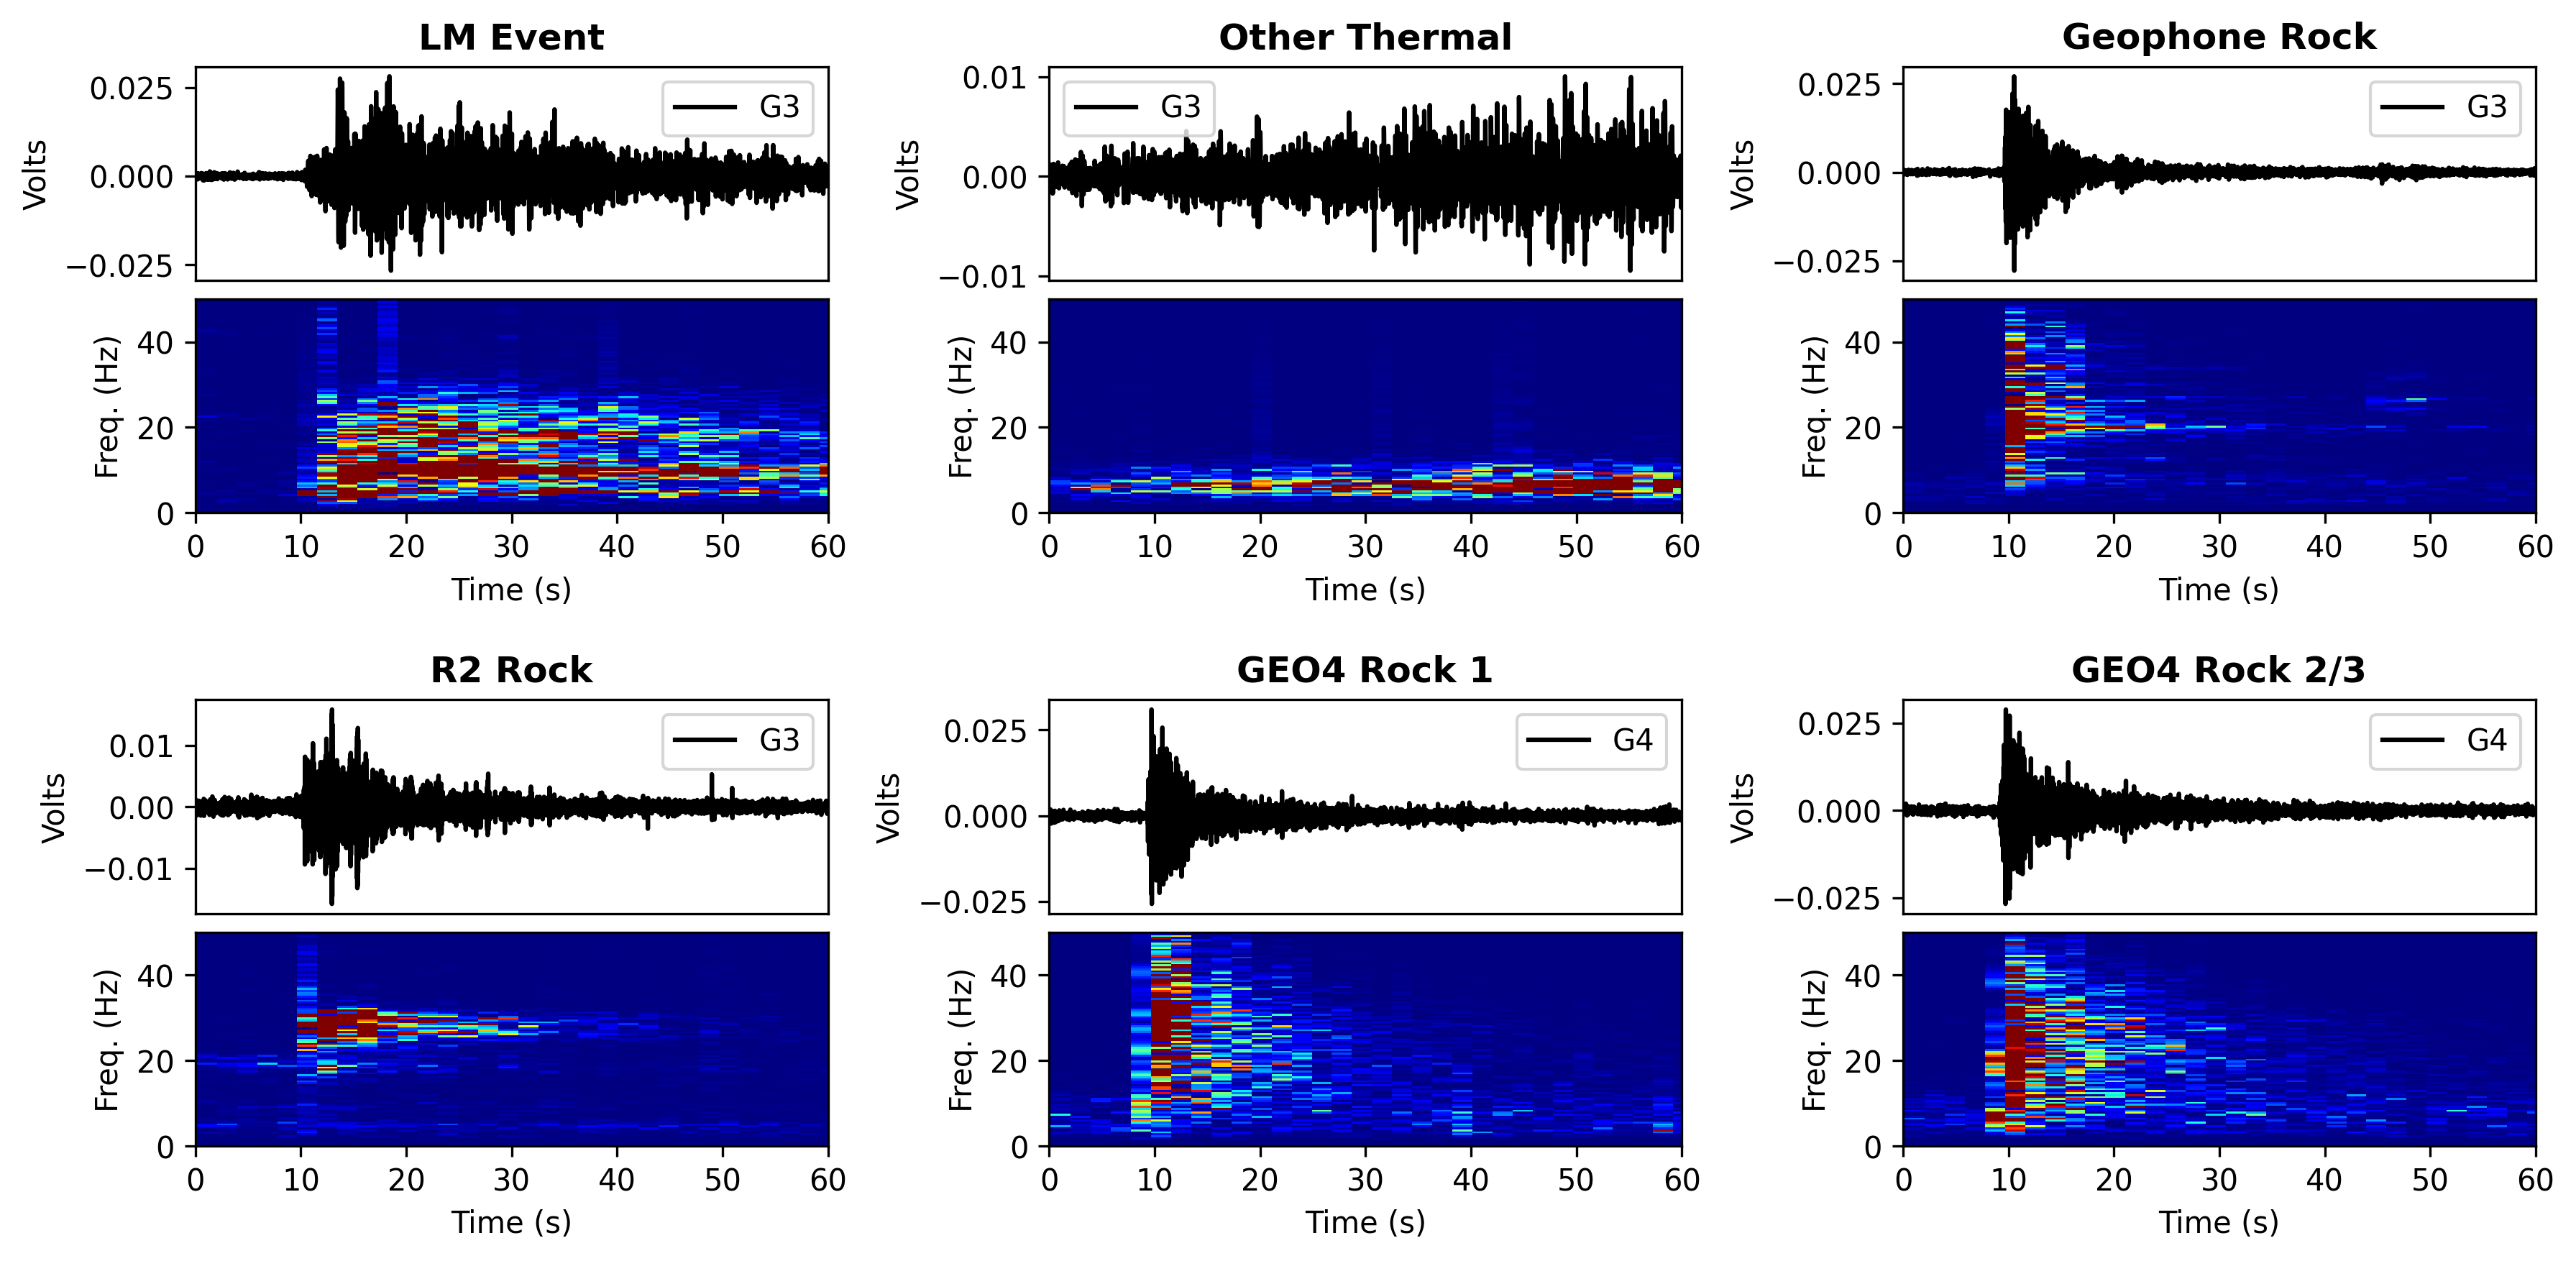

In [37]:
### Initialize figure
fig = plt.figure(figsize=(14., 6.5),dpi=300)
gs = gridspec.GridSpec(4, 3, wspace=0.35) 

### LM event
# Waveform
ax_LM = fig.add_subplot(gs[0,0])
ax_LM.plot(trtimes_LM,trdata_LM,color='black',label='G3')
ax_LM.set_xlim([0,60])
ax_LM.set_ylabel('Volts')
ax_LM.set_xticks([])
ax_LM.legend(loc='upper right')
ax_LM.set_title('LM Event',fontweight='bold')
# Spectrogram
ax_LM2 = fig.add_subplot(gs[1,0])
specmax = 8e-7
specax = ax_LM2.pcolormesh(times_LM, freqs_LM, spec_LM, cmap=cm.jet, vmax=specmax, shading='auto')
ax_LM2.set_xlim([0,60])
ax_LM2.set_ylim([0,50])
ax_LM2.set_ylabel('Freq. (Hz)')
ax_LM2.set_xlabel('Time (s)')

### Other thermal moonquake
# Waveform
ax_other = fig.add_subplot(gs[0,1])
ax_other.plot(trtimes_other,trdata_other,color='black',label='G3')
ax_other.set_xlim([0,60])
ax_other.set_ylabel('Volts')
ax_other.set_xticks([])
ax_other.legend(loc='upper left')
ax_other.set_title('Other Thermal',fontweight='bold')
# Spectrogram
ax_other2 = fig.add_subplot(gs[1,1])
specax = ax_other2.pcolormesh(times_other, freqs_other, spec_other, cmap=cm.jet, vmax=specmax, shading='auto')
ax_other2.set_xlim([0,60])
ax_other2.set_ylim([0,50])
ax_other2.set_ylabel('Freq. (Hz)')
ax_other2.set_xlabel('Time (s)') 

### Geophone Rock event
# Waveform
ax_georock = fig.add_subplot(gs[0,2])
ax_georock.plot(trtimes_georock,trdata_georock,color='black',label='G3')
ax_georock.set_xlim([0,60])
ax_georock.set_ylabel('Volts')
ax_georock.set_xticks([])
ax_georock.legend(loc='upper right')
ax_georock.set_title('Geophone Rock',fontweight='bold')
# Spectrogram
ax_georock2 = fig.add_subplot(gs[1,2])
specax = ax_georock2.pcolormesh(times_georock, freqs_georock, spec_georock, cmap=cm.jet, vmax=specmax, shading='auto')
ax_georock2.set_xlim([0,60])
ax_georock2.set_ylim([0,50])
ax_georock2.set_ylabel('Freq. (Hz)')
ax_georock2.set_xlabel('Time (s)')

### R2
# Waveform
ax_R2 = fig.add_subplot(gs[2,0])
ax_R2.plot(trtimes_R2,trdata_R2,color='black',label='G3')
ax_R2.set_xlim([0,60])
ax_R2.set_ylabel('Volts')
ax_R2.set_xticks([])
ax_R2.legend(loc='upper right')
ax_R2.set_title('R2 Rock',fontweight='bold')
# Spectrogram
ax_R22 = fig.add_subplot(gs[3,0])
specax = ax_R22.pcolormesh(times_R2, freqs_R2, spec_R2, cmap=cm.jet, vmax=specmax, shading='auto')
ax_R22.set_xlim([0,60])
ax_R22.set_ylim([0,50])
ax_R22.set_ylabel('Freq. (Hz)')
ax_R22.set_xlabel('Time (s)')

### Geophone 4 Rock 1
# Waveform
ax_rock1 = fig.add_subplot(gs[2,1])
ax_rock1.plot(trtimes_rock1, trdata_rock1,color='black',label='G4')
ax_rock1.set_xlim([0,60])
ax_rock1.set_ylabel('Volts')
ax_rock1.set_xticks([])
ax_rock1.legend(loc='upper right')
ax_rock1.set_title('GEO4 Rock 1',fontweight='bold')
# Spectrogram
ax_rock12 = fig.add_subplot(gs[3,1])
specax = ax_rock12.pcolormesh(times_rock1, freqs_rock1, spec_rock1, cmap=cm.jet, vmax=specmax, shading='auto')
ax_rock12.set_xlim([0,60])
ax_rock12.set_ylim([0,50])
ax_rock12.set_ylabel('Freq. (Hz)')
ax_rock12.set_xlabel('Time (s)')

### Geophone 4 Rock 2/3
# Waveform
ax_rock23 = fig.add_subplot(gs[2,2])
ax_rock23.plot(trtimes_rock23, trdata_rock23,color='black',label='G4')
ax_rock23.set_xlim([0,60])
ax_rock23.set_ylabel('Volts')
ax_rock23.set_xticks([])
ax_rock23.legend(loc='upper right')
ax_rock23.set_title('GEO4 Rock 2/3',fontweight='bold')
# Spectrogram
ax_rock232 = fig.add_subplot(gs[3,2])
specax = ax_rock232.pcolormesh(times_rock23, freqs_rock23, spec_rock23, cmap=cm.jet, vmax=specmax, shading='auto')
ax_rock232.set_xlim([0,60])
ax_rock232.set_ylim([0,50])
ax_rock232.set_ylabel('Freq. (Hz)')
ax_rock232.set_xlabel('Time (s)')

# Adjust plot distribution
plt.subplots_adjust(hspace = 0.35)
posn = ax_LM2.get_position()
ax_LM2.set_position([posn.x0, posn.y0+0.04, posn.width, posn.height])
posn = ax_other2.get_position()
ax_other2.set_position([posn.x0, posn.y0+0.04, posn.width, posn.height])
posn = ax_georock2.get_position()
ax_georock2.set_position([posn.x0, posn.y0+0.04, posn.width, posn.height])
posn = ax_R2.get_position()
ax_R2.set_position([posn.x0, posn.y0-0.04, posn.width, posn.height])
posn = ax_rock1.get_position()
ax_rock1.set_position([posn.x0, posn.y0-0.04, posn.width, posn.height])
posn = ax_rock23.get_position()
ax_rock23.set_position([posn.x0, posn.y0-0.04, posn.width, posn.height])

Text(0.5, 0, 'Time (s)')

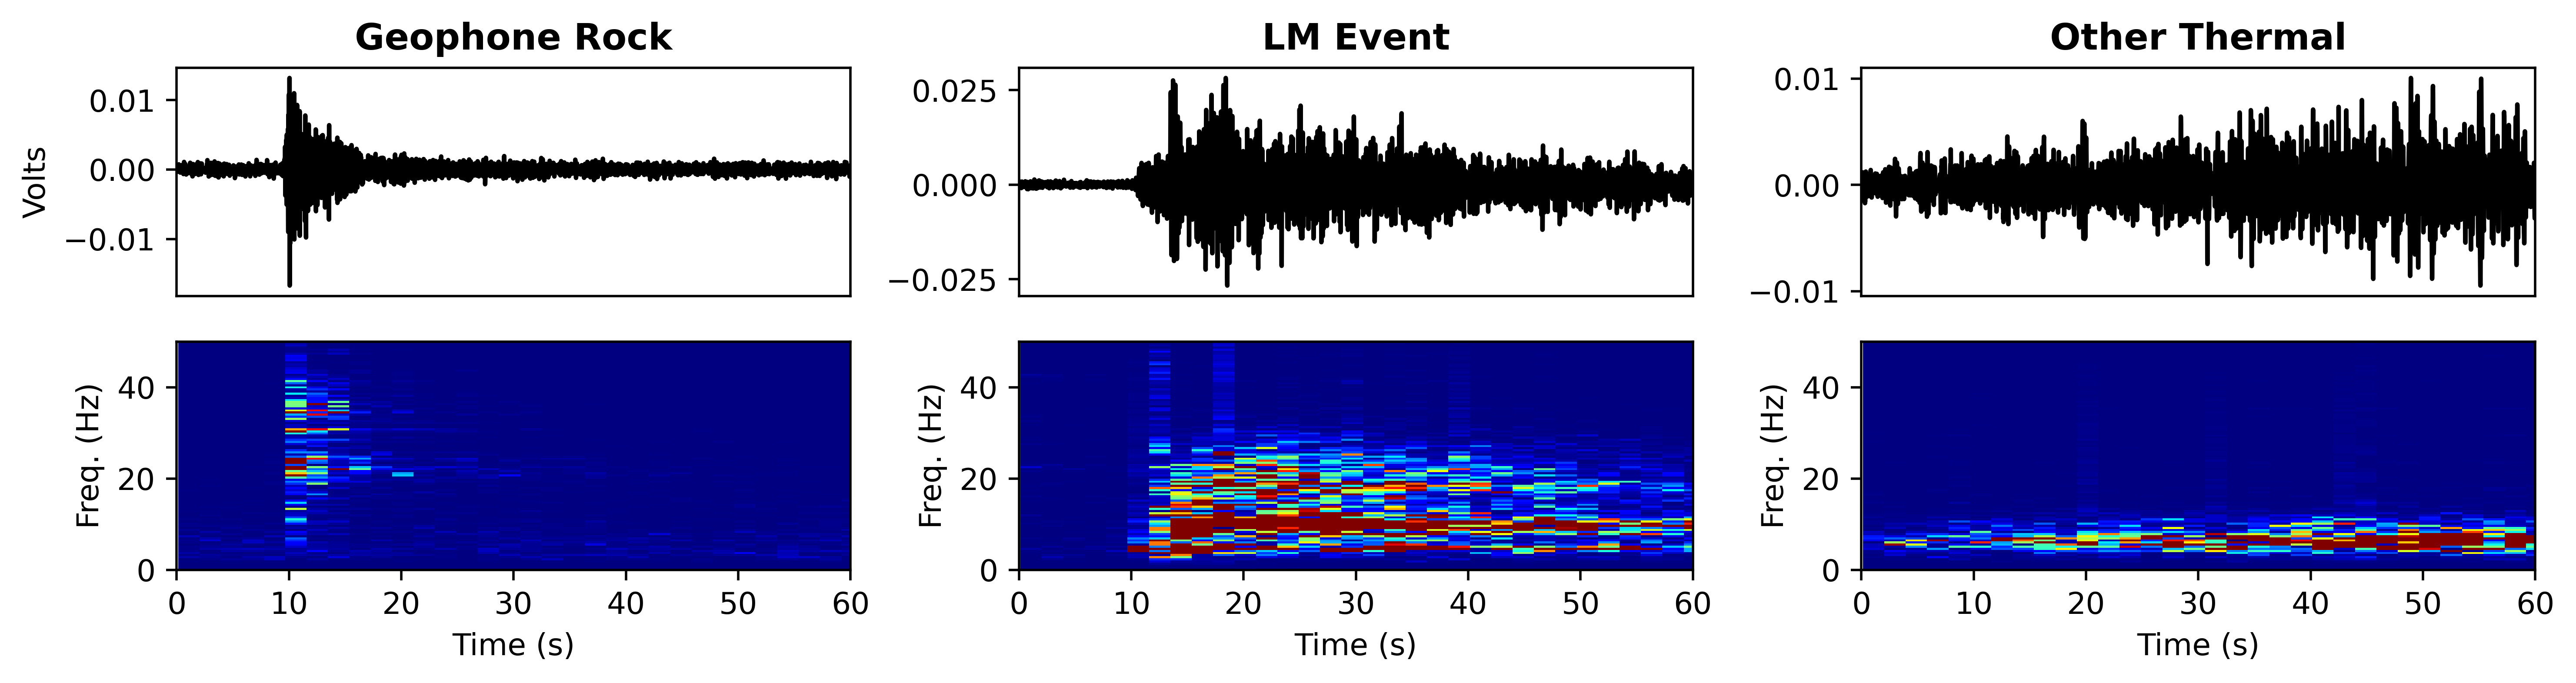

In [5]:
### Initialize figure
fig = plt.figure(figsize=(14., 7.),dpi=300)
gs = gridspec.GridSpec(4, 3, wspace=0.25) 

### Geophone Rock event
# Waveform
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(trtimes3_georock,trdata3_georock,color='black')
ax1.set_xlim([0,60])
ax1.set_ylabel('Volts')
ax1.set_xticks([])
ax1.set_title('Geophone Rock',fontweight='bold')
# Spectrogram
ax1b = fig.add_subplot(gs[1,0])
specmax = 1e-6
specax = ax1b.pcolormesh(t_georock, f_georock, Sxx_georock, cmap=cm.jet, vmax=specmax, shading='auto')
ax1b.set_xlim([0,60])
ax1b.set_ylim([0,50])
ax1b.set_ylabel('Freq. (Hz)')
ax1b.set_xlabel('Time (s)')

### LM Event
# Waveform
ax2 = fig.add_subplot(gs[0,1])
ax2.plot(trtimes3_LM,trdata3_LM,color='black')
ax2.set_xlim([0,60])
ax2.set_xticks([])
ax2.set_title('LM Event',fontweight='bold')
# Spectrogram
ax2b = fig.add_subplot(gs[1,1])
specax = ax2b.pcolormesh(t_LM, f_LM, Sxx_LM, cmap=cm.jet, vmax=specmax, shading='auto')
ax2b.set_xlim([0,60])
ax2b.set_ylim([0,50])
ax2b.set_ylabel('Freq. (Hz)')
ax2b.set_xlabel('Time (s)')

### Other event
# Waveform
ax3 = fig.add_subplot(gs[0,2])
ax3.plot(trtimes3_other,trdata3_other,color='black')
ax3.set_xlim([0,60])
ax3.set_xticks([])
ax3.set_title('Other Thermal',fontweight='bold')
# Spectrogram
ax3b = fig.add_subplot(gs[1,2])
specax = ax3b.pcolormesh(t_other, f_other, Sxx_other, cmap=cm.jet, vmax=specmax, shading='auto')
ax3b.set_xlim([0,60])
ax3b.set_ylim([0,50])
ax3b.set_ylabel('Freq. (Hz)')
ax3b.set_xlabel('Time (s)')